In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel

from dd_kable_analysis.config_loader import load_config

In [2]:
cfg = load_config()


In [3]:
output_root = Path(cfg.output_root)
traditional_dir = output_root / 'traditional_model' / 'first_level'


def collect_maps(base_dir: Path):
    ll_minus_ss_pattern = '*contrast-ll_minus_ss_output-effectsize.nii.gz'
    return sorted(base_dir.glob(f'sub-*/contrast_estimates/{ll_minus_ss_pattern}'))


def index_maps(paths):
    index = {}
    regex = re.compile(
        r'sub-(?P<sub>[^_]+)_ses-(?P<ses>[^_]+)_task-(?P<task>[^_]+)_'
        r'run-(?P<run>[^_]+)_ll_minus_ss_output-effectsize.nii.gz'
    )
    for p in paths:
        match = regex.search(p.name)
        if not match:
            continue
        key = (match.group('sub'), match.group('run'))
        index[key] = p
    return index

In [4]:
trad_maps = collect_maps(traditional_dir)
print(f'Num trad_maps = {len(trad_maps)}')

Num trad_maps = 439


In [5]:
design_matrix = pd.DataFrame({'intercept': np.ones(len(trad_maps))})


trad_slm = SecondLevelModel(smoothing_fwhm=cfg.smoothing_fwhm)
trad_slm = trad_slm.fit(trad_maps, design_matrix=design_matrix)
trad_zmap = trad_slm.compute_contrast(
    second_level_contrast='intercept', output_type='z_score'
)

Voxel index (i,j,k): (np.int64(35), np.int64(19), np.int64(41))
MNI coordinate (mm): (-26.5, -94.5, 3.5)
Min z-stat: -10.098


/tmp/ipykernel_26417/747010756.py:42: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  eroded_mask_resampled = image.resample_to_img(
/tmp/ipykernel_26417/747010756.py:42: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  eroded_mask_resampled = image.resample_to_img(


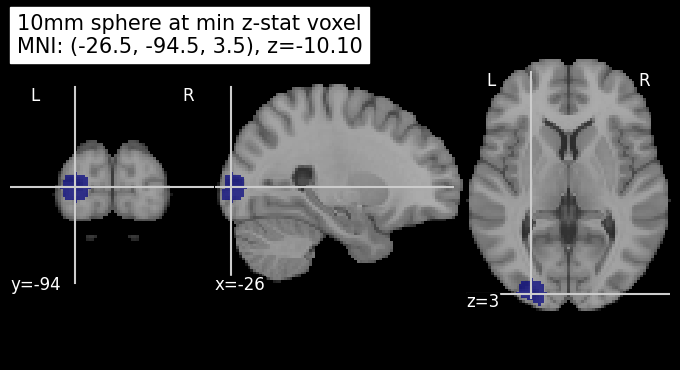

In [6]:
import numpy as np
from nilearn import image, plotting
from nilearn.maskers import NiftiSpheresMasker

# Find the voxel with the smallest (most negative) z-stat
zmap_data = trad_zmap.get_fdata()
affine = trad_zmap.affine

# Get flat index of minimum z-stat voxel
min_flat_idx = np.argmin(zmap_data)
min_vox_ijk = np.unravel_index(min_flat_idx, zmap_data.shape)
min_zstat = zmap_data[min_vox_ijk]

# Convert voxel index to MNI coordinates (mm)
min_coord_mni = image.coord_transform(*min_vox_ijk, affine)
print(f'Voxel index (i,j,k): {min_vox_ijk}')
print(f'MNI coordinate (mm): {min_coord_mni}')
print(f'Min z-stat: {min_zstat:.3f}')

# Build a sphere ROI image (10mm radius) at the min-z voxel
sphere_masker = NiftiSpheresMasker(
    seeds=[min_coord_mni],
    radius=10,
    mask_img=image.math_img('np.ones(img.shape[:3])', img=trad_zmap),
)
sphere_masker.fit(trad_zmap)
sphere_img = image.index_img(sphere_masker.inverse_transform(np.array([[1.0]])), 0)

# Erode the MNI brain mask then intersect with sphere
import nibabel as nib
from nilearn.datasets import load_mni152_brain_mask, load_mni152_template
from scipy.ndimage import binary_erosion

mni_mask = load_mni152_brain_mask(resolution=2)

# Erode by 2 voxels (~4mm at 2mm resolution) to move away from brain edge
eroded_data = binary_erosion(mni_mask.get_fdata().astype(bool), iterations=2).astype(
    np.int8
)
eroded_mask = nib.Nifti1Image(eroded_data, mni_mask.affine, mni_mask.header)

eroded_mask_resampled = image.resample_to_img(
    eroded_mask, sphere_img, interpolation='nearest'
)
sphere_img = image.math_img(
    'sphere * mask', sphere=sphere_img, mask=eroded_mask_resampled
)

# Plot the sphere on top of the MNI template
mni_bg = load_mni152_template(resolution=2)

plotting.plot_roi(
    sphere_img,
    bg_img=mni_bg,
    title=f'10mm sphere at min z-stat voxel\nMNI: {tuple(round(c, 1) for c in min_coord_mni)}, z={min_zstat:.2f}',
    display_mode='ortho',
    cut_coords=min_coord_mni,
    draw_cross=True,
    colorbar=False,
)
plt.show()


In [7]:
from dd_kable_analysis.mvpa.decode import decode_subject_atlas_rois_clf

# The sphere_img has values of 1 inside the sphere, so label 1 = our single ROI.
# decode_subject_atlas_rois_clf treats it as a one-ROI atlas.
sub_id = 'dmp0330'  # <-- change subject ID here

roi_summary_df = decode_subject_atlas_rois_clf(
    cfg,
    sub_id=sub_id,
    atlas_img=sphere_img,
    y_col='choseAccept',
    verbose=True,
)


[dmp0330] QA-passed runs: ['1', '2', '3']
[dmp0330] trial regressors in design (pre-filter): 87
[dmp0330] omitted high-VIF trials: 1
[dmp0330] missing beta files: 0
[dmp0330] kept trials (post-filter): 86
[dmp0330] kept by run: {'1': 28, '2': 29, '3': 29}
[dmp0330] runs with >= 20 kept trials: ['1', '2', '3']
[global] X_all=(86, 240143) (mask vox=240143) y=(86,) groups=(86,)
[global] trials per run:
 1    28
2    29
3    29
[roi map] n_rois=1
[roi map] voxels per ROI percentiles: [433. 433. 433. 433. 433.]


In [8]:
print(
    roi_summary_df[
        ['roi_label', 'n_vox_preQC', 'n_vox_postQC', 'roc_auc', 'balanced_accuracy']
    ].to_string(index=False)
)

 roi_label  n_vox_preQC  n_vox_postQC  roc_auc  balanced_accuracy
         1          433           433 0.421978           0.496703


In [9]:
cfg

Config(data_root=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable'), fmriprep_dir=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/fmriprep'), bids_dir=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/bids/ds002843'), subject_lists=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/subject_lists'), output_root=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_output'), task_name='itc', bold_func_glob='ses-{ses}/func/', bold_data_suffix='space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz', mask_data_suffix='space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz', behav_func_glob='ses-{ses}/func/', behav_data_suffix='*events.tsv', masks_dir=PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks'), confounds=ConfoundsConfig(patterns=['^cosine\\d{2}$', '^rot_[xyz]$', '^rot_[xyz]_derivative1$'], compiled_patterns=[re.compile('^cosine\\d{2}$'),

In [10]:
from pathlib import Path

# Get first 20 MVPA subject IDs from cfg.subject_lists/mvpa_subject_list.txt
subject_list_file = Path(cfg.subject_lists) / 'mvpa_subject_list.txt'
if not subject_list_file.exists():
    raise FileNotFoundError(f'Missing subject list: {subject_list_file}')

with subject_list_file.open() as f:
    sub_ids = [line.strip() for line in f if line.strip()]

sub_ids_50 = sub_ids[:50]
print(f'Using {len(sub_ids_50)} subjects from: {subject_list_file}')
print(sub_ids_50)

rows = []
for sid in sub_ids_50:
    try:
        one_df = decode_subject_atlas_rois_clf(
            cfg,
            sub_id=sid,
            atlas_img=sphere_img,
            y_col='choseAccept',
            verbose=False,
        ).copy()
        one_df['sub_id'] = sid
        rows.append(one_df)
        print(f'[{sid}] ok')
    except Exception as e:
        print(f'[{sid}] failed: {e}')

if len(rows) == 0:
    raise RuntimeError('No subject summaries were produced.')

biased_roi_summary_50 = pd.concat(rows, ignore_index=True)
biased_roi_summary_50 = biased_roi_summary_50[
    [
        'sub_id',
        'roi_label',
        'n_trials',
        'n_runs',
        'n_vox_preQC',
        'n_vox_postQC',
        'roc_auc',
        'balanced_accuracy',
        'accuracy',
        'sensitivity',
        'specificity',
        'log_loss',
        'mean_C',
    ]
]

print(f'Combined rows: {len(biased_roi_summary_50)}')
biased_roi_summary_50.head()

Using 50 subjects from: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/subject_lists/mvpa_subject_list.txt
['dmp0011', 'dmp0019', 'dmp0048', 'dmp0060', 'dmp0062', 'dmp0063', 'dmp0090', 'dmp0095', 'dmp0097', 'dmp0098', 'dmp0106', 'dmp0109', 'dmp0115', 'dmp0118', 'dmp0140', 'dmp0148', 'dmp0153', 'dmp0154', 'dmp0157', 'dmp0169', 'dmp0171', 'dmp0183', 'dmp0188', 'dmp0217', 'dmp0219', 'dmp0229', 'dmp0269', 'dmp0273', 'dmp0295', 'dmp0301', 'dmp0305', 'dmp0313', 'dmp0330', 'dmp0350', 'dmp0356', 'dmp0357', 'dmp0381', 'dmp0414', 'dmp0418', 'dmp0442', 'dmp0445', 'dmp0492', 'dmp0498', 'dmp0502', 'dmp0509', 'dmp0510', 'dmp0521', 'dmp0523', 'dmp0528', 'dmp0556']
[dmp0011] ok
[dmp0019] ok
[dmp0048] ok
[dmp0060] ok
[dmp0062] ok
[dmp0063] failed: ❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.
[dmp0090] ok
[dmp0095] ok
[dmp0097] ok
[dmp0098] ok
[dmp0106] ok
[dmp0109] ok
[dmp0115] ok
[dmp0118] ok
[dmp0140] ok
[dmp0148] failed: [dmp0148] has only 2 QA-passed runs; 

,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,roc_auc,balanced_accuracy,accuracy,sensitivity,specificity,log_loss,mean_C
0,dmp0011,1,116,4,433,433,0.575425,0.600067,0.603448,0.589744,0.610390,0.703497,0.000550
1,dmp0019,1,115,4,433,433,0.458128,0.497126,0.495652,0.494253,0.500000,0.688570,0.000866
2,dmp0048,1,116,4,433,433,0.666096,0.629832,0.603448,0.702703,0.556962,0.709457,0.001199
3,dmp0060,1,83,3,433,433,0.869231,0.763187,0.759036,0.769231,0.757143,0.533569,0.040000
4,dmp0062,1,116,4,433,433,0.331175,0.372186,0.362069,0.318841,0.425532,0.699746,0.000100


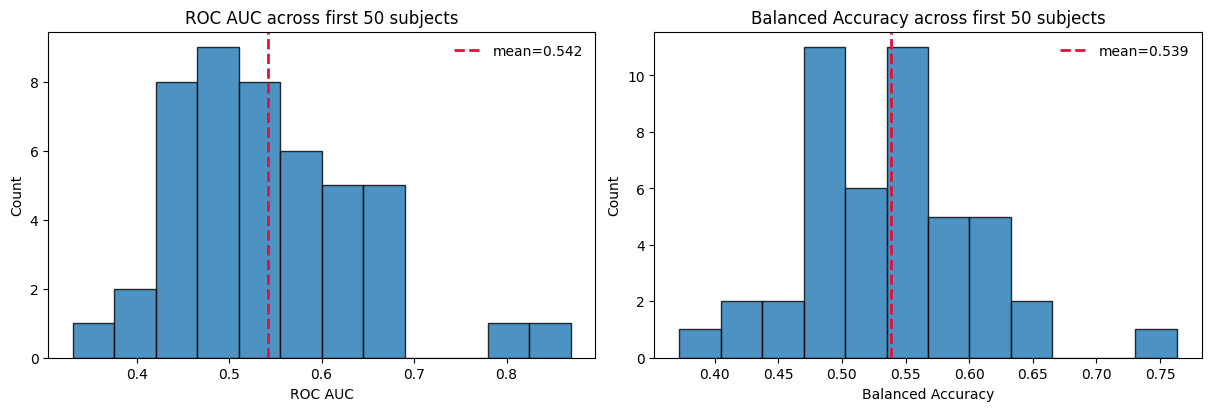

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

metrics = [
    ('roc_auc', 'ROC AUC'),
    ('balanced_accuracy', 'Balanced Accuracy'),
]

for ax, (col, label) in zip(axes, metrics):
    vals = biased_roi_summary_50[col].dropna()
    ax.hist(vals, bins=12, edgecolor='black', alpha=0.8)
    ax.axvline(
        vals.mean(),
        color='crimson',
        linestyle='--',
        linewidth=2,
        label=f'mean={vals.mean():.3f}',
    )
    ax.set_title(f'{label} across first 50 subjects')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(frameon=False)

plt.show()


In [13]:
biased_roi_summary_50

,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,roc_auc,balanced_accuracy,accuracy,sensitivity,specificity,log_loss,mean_C
0,dmp0011,1,116,4,433,433,0.575425,0.600067,0.603448,0.589744,0.610390,0.703497,0.000550
1,dmp0019,1,115,4,433,433,0.458128,0.497126,0.495652,0.494253,0.500000,0.688570,0.000866
2,dmp0048,1,116,4,433,433,0.666096,0.629832,0.603448,0.702703,0.556962,0.709457,0.001199
3,dmp0060,1,83,3,433,433,0.869231,0.763187,0.759036,0.769231,0.757143,0.533569,0.040000
4,dmp0062,1,116,4,433,433,0.331175,0.372186,0.362069,0.318841,0.425532,0.699746,0.000100
5,dmp0090,1,116,4,433,433,0.586039,0.536526,0.629310,0.715909,0.357143,0.627542,0.013696
6,dmp0095,1,116,4,433,433,0.493912,0.510552,0.663793,0.214286,0.806818,0.654817,0.013696
7,dmp0097,1,116,4,433,433,0.619318,0.629870,0.715517,0.464286,0.795455,0.596713,0.010000
8,dmp0098,1,116,4,433,433,0.520515,0.543875,0.551724,0.452830,0.634921,0.729918,0.003566
9,dmp0106,1,87,3,433,433,0.478378,0.480811,0.459770,0.621622,0.340000,0.697284,0.000100


# Try a couple of Pauli ROIs

In [ ]:
pauli_dir = Path(
    '/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145'
)
pauli_atlas = nib.load(pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask.nii.gz')


## Pauli ROI 3 choice decoding

In [15]:
from pathlib import Path

import nibabel as nib

from dd_kable_analysis.mvpa.decode import decode_subject_atlas_rois_clf

pauli_dir = Path(
    '/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145'
)
pauli_atlas_path = pauli_dir / 'pauli_roi_atlas_thr0.50_to-groupmask.nii.gz'
pauli_atlas = nib.load(pauli_atlas_path)

pauli_roi_label = 3
pauli_roi3_data = (pauli_atlas.get_fdata() == pauli_roi_label).astype(
    np.int16
) * pauli_roi_label
pauli_roi3_img = nib.Nifti1Image(
    pauli_roi3_data, pauli_atlas.affine, pauli_atlas.header
)

print(f'Loaded Pauli atlas: {pauli_atlas_path}')
print(f'Using ROI label: {pauli_roi_label}')
print(f'ROI voxel count: {int((pauli_roi3_data > 0).sum())}')

if 'sub_ids_50' not in globals():
    subject_list_file = Path(cfg.subject_lists) / 'mvpa_subject_list.txt'
    with subject_list_file.open() as f:
        sub_ids_50 = [line.strip() for line in f if line.strip()][:50]

pauli_rows = []
for sid in sub_ids_50:
    try:
        roi_summary_df, trialwise_df = decode_subject_atlas_rois_clf(
            cfg,
            sub_id=sid,
            atlas_img=pauli_roi3_img,
            y_col='choseAccept',
            verbose=False,
            return_trialwise=True,
            trialwise_rois={pauli_roi_label},
        )
        one_row = roi_summary_df.copy()
        one_row['true_outcome_rate'] = float(trialwise_df['y'].mean())
        one_row['n_positive_trials'] = int(trialwise_df['y'].sum())
        one_row['n_trialwise_rows'] = int(len(trialwise_df))
        pauli_rows.append(one_row)
        print(f'[{sid}] ok')
    except Exception as e:
        print(f'[{sid}] failed: {e}')

if len(pauli_rows) == 0:
    raise RuntimeError('No Pauli ROI summaries were produced.')

pauli_roi3_summary_50 = pd.concat(pauli_rows, ignore_index=True)
pauli_roi3_summary_50 = pauli_roi3_summary_50[
    [
        'sub_id',
        'roi_label',
        'n_trials',
        'n_runs',
        'n_vox_preQC',
        'n_vox_postQC',
        'true_outcome_rate',
        'n_positive_trials',
        'roc_auc',
        'balanced_accuracy',
        'accuracy',
        'sensitivity',
        'specificity',
        'log_loss',
        'mean_C',
    ]
]

print(f'Combined rows: {len(pauli_roi3_summary_50)}')
pauli_roi3_summary_50.head()


Loaded Pauli atlas: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145/pauli_roi_atlas_thr0.50_to-groupmask.nii.gz
Using ROI label: 3
ROI voxel count: 122
[dmp0011] ok
[dmp0019] ok
[dmp0048] ok
[dmp0060] ok
[dmp0062] ok
[dmp0063] failed: ❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.
[dmp0090] ok
[dmp0095] ok
[dmp0097] ok
[dmp0098] ok
[dmp0106] ok
[dmp0109] ok
[dmp0115] ok
[dmp0118] ok
[dmp0140] failed: 'roi_label'
[dmp0148] failed: [dmp0148] has only 2 QA-passed runs; requires >= 3.
[dmp0153] ok
[dmp0154] ok
[dmp0157] ok
[dmp0169] ok
[dmp0171] ok
[dmp0183] ok
[dmp0188] ok
[dmp0217] ok
[dmp0219] ok
[dmp0229] ok
[dmp0269] ok
[dmp0273] failed: 'roi_label'
[dmp0295] ok
[dmp0301] ok
[dmp0305] ok
[dmp0313] failed: 'roi_label'
[dmp0330] ok
[dmp0350] ok
[dmp0356] ok
[dmp0357] ok
[dmp0381] ok
[dmp0414] ok
[dmp0418] ok
[dmp0442] failed: 'roi_label'
[dmp0445] ok
[dmp0492] failed: [dmp0492] has onl

,sub_id,roi_label,n_trials,n_runs,n_vox_preQC,n_vox_postQC,true_outcome_rate,n_positive_trials,roc_auc,balanced_accuracy,accuracy,sensitivity,specificity,log_loss,mean_C
0,dmp0011,3,116,4,122,112,0.336207,39,0.387279,0.478188,0.517241,0.358974,0.597403,0.695973,0.000920
1,dmp0019,3,115,4,122,121,0.756522,87,0.526683,0.530993,0.565217,0.597701,0.464286,0.676518,0.006041
2,dmp0048,3,116,4,122,122,0.318966,37,0.475881,0.507355,0.534483,0.432432,0.582278,0.715226,0.002800
3,dmp0060,3,83,3,122,63,0.156627,13,0.420879,0.467033,0.734940,0.076923,0.857143,0.574676,0.054415
4,dmp0062,3,116,4,122,122,0.594828,69,0.480111,0.497842,0.491379,0.463768,0.531915,0.705457,0.001091


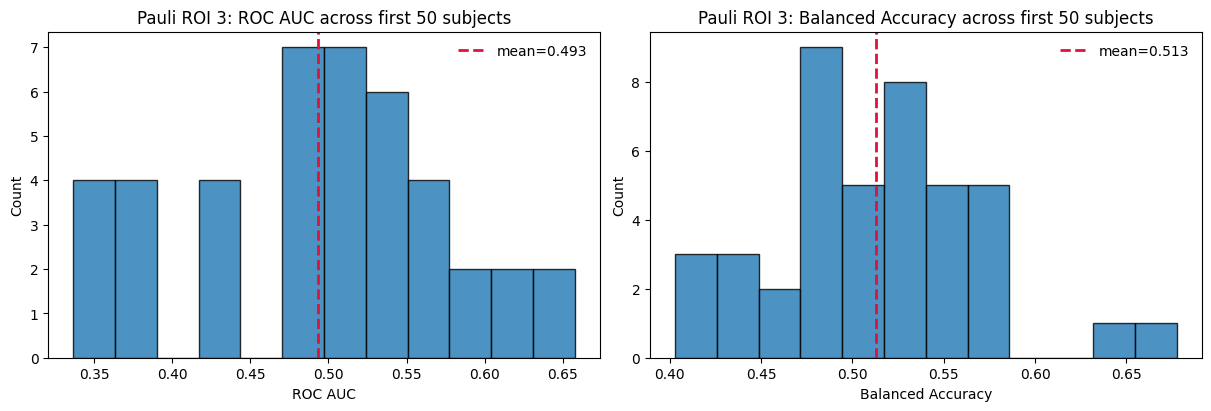

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

metrics = [
    ('roc_auc', 'ROC AUC'),
    ('balanced_accuracy', 'Balanced Accuracy'),
]

for ax, (col, label) in zip(axes, metrics):
    vals = pauli_roi3_summary_50[col].dropna()
    ax.hist(vals, bins=12, edgecolor='black', alpha=0.8)
    ax.axvline(
        vals.mean(),
        color='crimson',
        linestyle='--',
        linewidth=2,
        label=f'mean={vals.mean():.3f}',
    )
    ax.set_title(f'Pauli ROI 3: {label} across first 50 subjects')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(frameon=False)

plt.show()


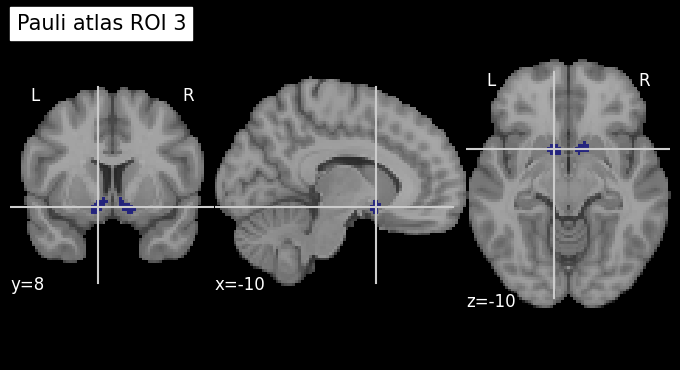

In [17]:
from nilearn.datasets import load_mni152_template
from nilearn.plotting import plot_roi

mni_bg = load_mni152_template(resolution=2)

plot_roi(
    pauli_roi3_img,
    bg_img=mni_bg,
    title='Pauli atlas ROI 3',
    display_mode='ortho',
    draw_cross=True,
    colorbar=False,
)
plt.show()
